In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

PROCESSED_PATH = "../data/processed/"
VISUAL_PATH = "../visualization/"

In [2]:
df = pd.read_csv(PROCESSED_PATH + "ecommerce_main_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (113425, 42)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,order_year,order_month,order_month_name,order_year_month,delivery_time_days,estimated_delivery_days,is_late_delivery,is_delivered
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP,38.71,1.0,voucher,4.0,2017,10,October,2017-10,8.0,15,0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP,141.46,1.0,boleto,4.0,2018,7,July,2018-07,13.0,19,0,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP,179.12,3.0,credit_card,5.0,2018,8,August,2018-08,9.0,26,0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,31842.0,belo horizonte,MG,72.20,1.0,credit_card,5.0,2017,11,November,2017-11,13.0,26,0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,8752.0,mogi das cruzes,SP,28.62,1.0,credit_card,5.0,2018,2,February,2018-02,2.0,12,0,1


In [3]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [4]:
df_delivered = df[df["order_status"] == "delivered"].copy()

print("Delivered orders shape:", df_delivered.shape)
print("Total unique customers:", df_delivered["customer_unique_id"].nunique())

Delivered orders shape: (110197, 42)
Total unique customers: 93358


In [5]:
max_order_date = df_delivered["order_purchase_timestamp"].max()
reference_date = max_order_date + pd.Timedelta(days=1)

print("Last order date:", max_order_date)
print("Reference date:", reference_date)

Last order date: 2018-08-29 15:00:37
Reference date: 2018-08-30 15:00:37


In [6]:
rfm = df_delivered.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (reference_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum"
}).reset_index()

rfm.columns = ["customer_unique_id", "recency", "frequency", "monetary"]

rfm.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [7]:
rfm.describe()

,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,211.831449
std,152.591453,0.209097,642.163458
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.760000
50%,219.000000,1.000000,112.950000
75%,346.000000,1.000000,201.740000
max,714.000000,15.000000,109312.640000


In [8]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
).astype(int)

rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm["RFM_total_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_total_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7


In [9]:
def segment_customer(row):
    if row["RFM_total_score"] >= 13:
        return "High Value Customer"
    elif row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Loyal Customer"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk Customer"
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Lost Customer"
    elif row["R_score"] >= 4 and row["F_score"] <= 2:
        return "New Customer"
    else:
        return "Regular Customer"

rfm["customer_segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_total_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,9,New Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,6,New Customer
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4,Lost Customer
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4,Lost Customer
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7,Lost Customer


In [10]:
segment_summary = rfm.groupby("customer_segment", as_index=False).agg({
    "customer_unique_id": "nunique",
    "recency": "mean",
    "frequency": "mean",
    "monetary": "mean",
    "RFM_total_score": "mean"
})

segment_summary = segment_summary.rename(columns={
    "customer_unique_id": "total_customers",
    "recency": "avg_recency",
    "frequency": "avg_frequency",
    "monetary": "avg_monetary",
    "RFM_total_score": "avg_rfm_score"
})

segment_summary = segment_summary.sort_values(by="total_customers", ascending=False)

segment_summary

,customer_segment,total_customers,avg_recency,avg_frequency,avg_monetary,avg_rfm_score
5,Regular Customer,24636,185.825743,1.011731,172.416722,9.181604
0,At Risk Customer,22230,394.662213,1.047998,212.109696,8.498381
2,Lost Customer,14986,395.508141,1.000000,214.800655,5.951154
4,New Customer,14984,90.878404,1.000000,204.358699,8.994261
3,Loyal Customer,8546,97.210040,1.018488,81.778520,10.926398
1,High Value Customer,7976,93.136911,1.201354,480.605683,13.550025


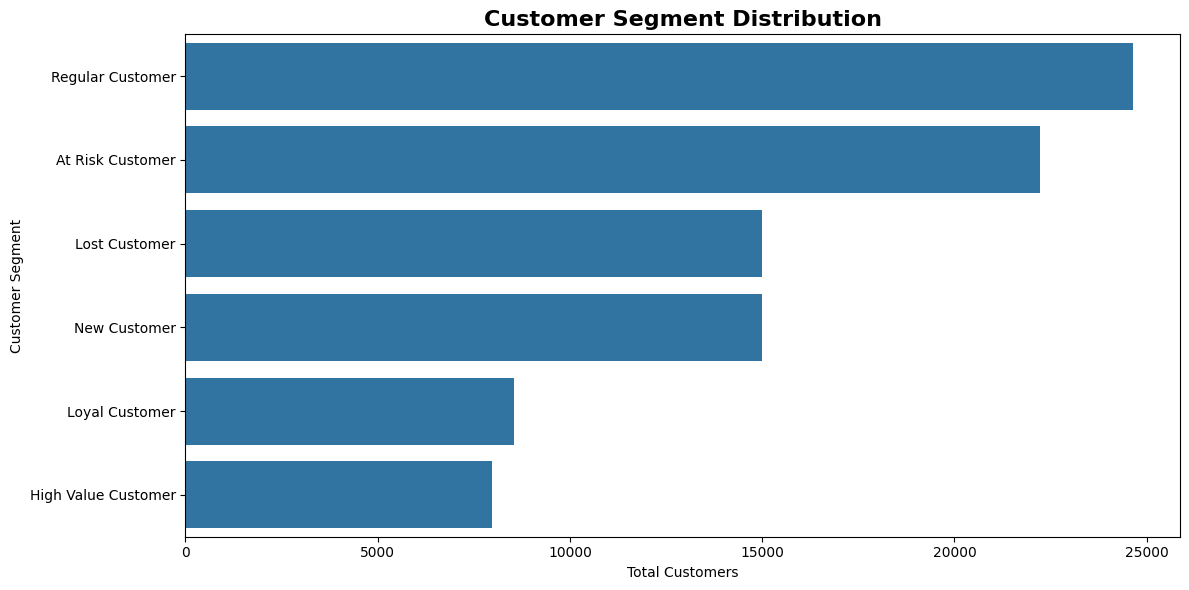

In [11]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_summary,
    x="total_customers",
    y="customer_segment"
)

plt.title("Customer Segment Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Total Customers")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "customer_segment_distribution.png", dpi=300)
plt.show()

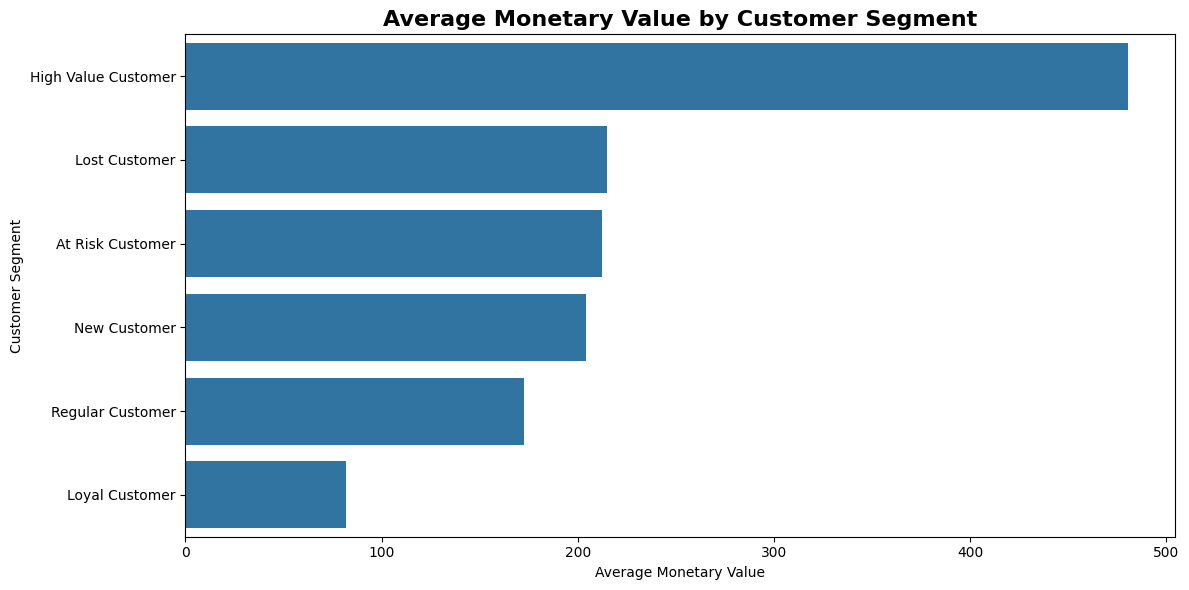

In [12]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_summary.sort_values(by="avg_monetary", ascending=False),
    x="avg_monetary",
    y="customer_segment"
)

plt.title("Average Monetary Value by Customer Segment", fontsize=16, fontweight="bold")
plt.xlabel("Average Monetary Value")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "avg_monetary_by_segment.png", dpi=300)
plt.show()

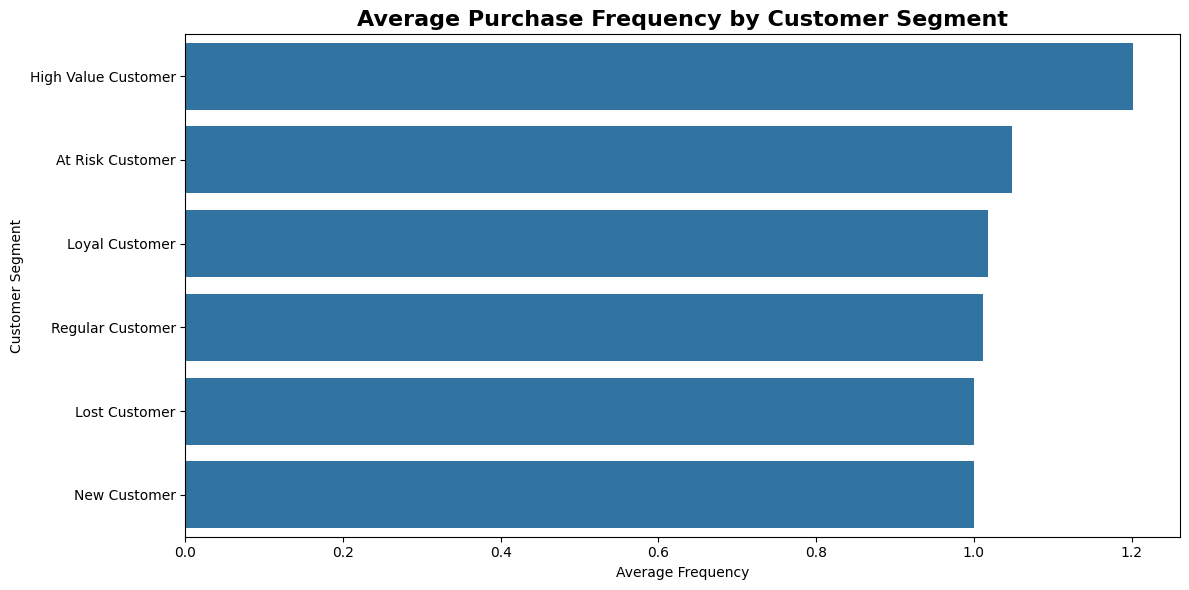

In [13]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_summary.sort_values(by="avg_frequency", ascending=False),
    x="avg_frequency",
    y="customer_segment"
)

plt.title("Average Purchase Frequency by Customer Segment", fontsize=16, fontweight="bold")
plt.xlabel("Average Frequency")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "avg_frequency_by_segment.png", dpi=300)
plt.show()

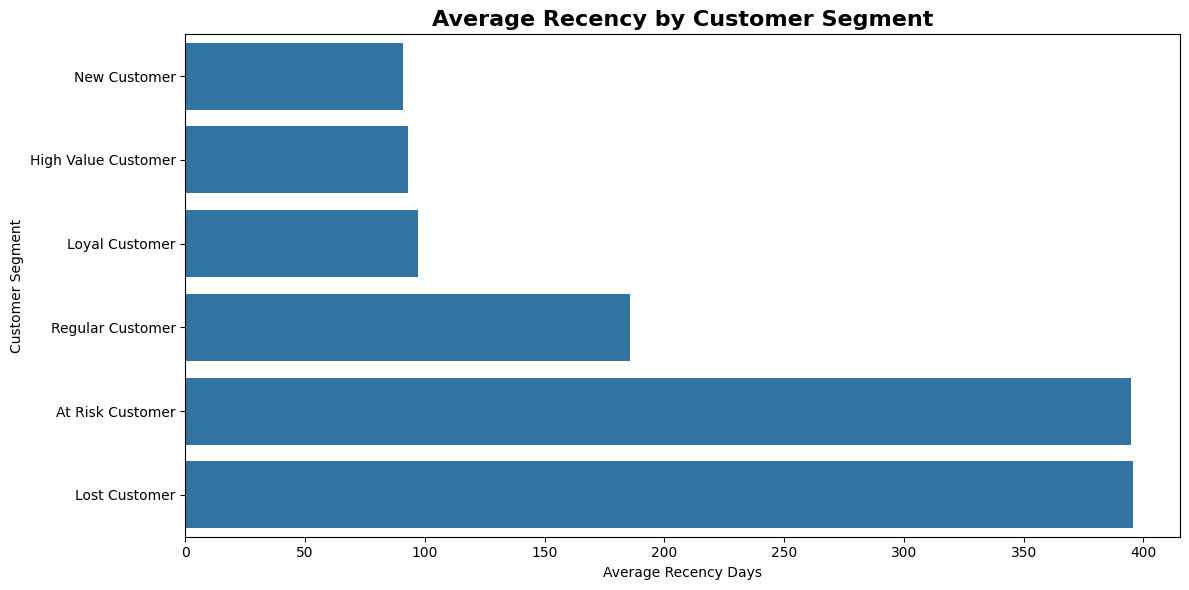

In [14]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_summary.sort_values(by="avg_recency", ascending=True),
    x="avg_recency",
    y="customer_segment"
)

plt.title("Average Recency by Customer Segment", fontsize=16, fontweight="bold")
plt.xlabel("Average Recency Days")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "avg_recency_by_segment.png", dpi=300)
plt.show()

In [15]:
high_value_customers = rfm[rfm["customer_segment"] == "High Value Customer"].sort_values(
    by="monetary",
    ascending=False
).head(20)

high_value_customers

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_total_score,customer_segment
87448,ef8d54b3797ea4db1d63f0ced6a906e9,133,1,30186.00,4,5,5,455,14,High Value Customer
43168,763c8b1c9c68a0229c42c9fc6f662b93,46,1,29099.52,5,3,5,535,13,High Value Customer
73127,c8460e4251689ba205045f3ea17884a1,22,4,27935.46,5,5,5,555,15,High Value Customer
85765,eae0a83d752b1dd32697e0e7b4221656,127,2,25051.89,4,5,5,455,14,High Value Customer
63528,adfa1cab2b2c8706db21bb13c0a1beb1,89,1,19457.04,5,4,5,545,14,High Value Customer
93346,fff5eb4918b2bf4b2da476788d42051c,58,1,17069.76,5,5,5,555,15,High Value Customer
69578,be825ddd3b40db3f91bf05b4e9435d56,79,1,12490.88,5,4,5,545,14,High Value Customer
52601,906a8a4ec9f3d4c3e64fa6d1c4fe6009,41,2,11881.01,5,5,5,555,15,High Value Customer
73378,c8ed31310fc440a3f8031b177f9842c3,18,1,11572.80,5,4,5,545,14,High Value Customer
92690,fe2b2f70f3dc31c23319ae1029eac77f,173,1,11531.41,4,5,5,455,14,High Value Customer


In [16]:
rfm.to_csv(PROCESSED_PATH + "customer_rfm_analysis.csv", index=False)
segment_summary.to_csv(PROCESSED_PATH + "customer_segment_summary.csv", index=False)
high_value_customers.to_csv(PROCESSED_PATH + "high_value_customers.csv", index=False)

print("Customer analysis files saved successfully!")
print("RFM shape:", rfm.shape)
print("Segment summary shape:", segment_summary.shape)

Customer analysis files saved successfully!
RFM shape: (93358, 10)
Segment summary shape: (6, 6)


In [17]:
segment_summary

,customer_segment,total_customers,avg_recency,avg_frequency,avg_monetary,avg_rfm_score
5,Regular Customer,24636,185.825743,1.011731,172.416722,9.181604
0,At Risk Customer,22230,394.662213,1.047998,212.109696,8.498381
2,Lost Customer,14986,395.508141,1.000000,214.800655,5.951154
4,New Customer,14984,90.878404,1.000000,204.358699,8.994261
3,Loyal Customer,8546,97.210040,1.018488,81.778520,10.926398
1,High Value Customer,7976,93.136911,1.201354,480.605683,13.550025
